<a href="https://colab.research.google.com/github/EzequielBrunet/telco-churn-analysis/blob/main/Proyecto_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Análisis Exploratorio y de Impacto Económico - Telco Customer Churn
**Autor:** Ezequiel brunet

**Fecha de inicio:** 25/03/2026  

**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv


## 1. Contexto de negocio

Una empresa de telecomunicaciones necesita identificar qué clientes tienen
mayor probabilidad de abandonar el servicio (churn) antes de que suceda.

Retener un cliente existente cuesta entre 5 y 7 veces menos que adquirir
uno nuevo, por lo que anticipar el abandono permite diseñar estrategias de
retención más eficientes y reducir el impacto económico.

## 2. Hipótesis

**Hipótesis principal:**  
Los clientes con contrato mensual, menos de 12 meses de antigüedad y cargos
mensuales elevados tienen mayor probabilidad de abandonar el servicio.
Por el contrario, los clientes con mayor antigüedad tienden a mantenerse
independientemente del tipo de contrato y del precio que paguen.

**Hipótesis secundarias:**
- El tipo de contrato (mensual vs. anual) es el factor con mayor influencia
  en el churn durante los primeros meses.
- Los clientes nuevos (tenure < 12 meses) son más vulnerables al abandono.
- Los clientes que pagan más sin tener servicios adicionales tienden a irse más.
- A partir de cierto umbral de antigüedad, la lealtad del cliente supera
  el peso del precio y el tipo de contrato.

**Objetivo del modelo:**  
Clasificar a cada cliente como propenso o no propenso al churn, utilizando
algoritmos de aprendizaje supervisado, e identificar el punto de antigüedad
a partir del cual el riesgo de abandono disminuye significativamente.

## 3. Descripción del dataset

| Característica | Detalle |
|---|---|
| Fuente | IBM Sample Data / Kaggle |
| Filas | 7.043 clientes |
| Columnas | 21 variables |
| Variable objetivo | Churn (Yes / No) |

**Variables principales:**
- `tenure` — meses de antigüedad del cliente
- `Contract` — tipo de contrato (mensual, anual, dos años)
- `MonthlyCharges` — cargo mensual en dólares
- `TotalCharges` — cargo total acumulado
- `Churn` — si el cliente abandonó o no (variable objetivo)

## 4. Etapas del proyecto

- [x] Carga del dataset
- [x] Exploración inicial (shape, dtypes, describe)
- [x] Limpieza de datos
- [x] Análisis exploratorio (EDA)
- [x] Visualizaciones
- [x] Conclución y recomendaciones

In [4]:
#Importamos las librerias que se van a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [5]:
#Le doy permiso a Google Colap a que ingrese a drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/content/drive/MyDrive/ProyectoData/Archivo.csv')

In [7]:
# Dimensiones del dataset
print(df.shape)

# Tipos de datos de cada columna
print(df.dtypes)

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
# Estadísticas básicas con NumPy incluido
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 5. Limpieza de datos

Antes de analizar el dataset es necesario garantizar que los datos
sean consistentes y confiables. Se revisaron los siguientes puntos:

**Problemas identificados:**
- `TotalCharges` fue importada como texto (object) en lugar de
  número (float64) debido a espacios en blanco en el CSV original.
- Filas con valores nulos generados al convertir esa columna.
- Filas duplicadas detectadas.
- `customerID` no aporta valor predictivo al modelo.

**Acciones realizadas:**
1. Convertir `TotalCharges` a tipo numérico.
2. Eliminar filas con valores nulos (11 filas).
3. Eliminar filas duplicadas (22 filas).
4. Eliminar la columna `customerID`.

**Resultados de la limpieza:**
- Filas eliminadas por nulos en TotalCharges: 11
- Filas duplicadas eliminadas: 22
- Nulos restantes: 0
- Dataset final: 7010 filas y 20 columnas

In [36]:
# Exploración antes de limpiar
print('Valores previos a la limpieza')
print(df['Churn'].value_counts())


Valores previos a la limpieza
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [10]:
# Paso 1 - ver nulos antes de limpiar
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eliminar nulos
df.dropna(inplace=True)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Eliminar customerID
df.drop(columns=['customerID'], inplace=True, errors='ignore')

In [12]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(7032, 20)
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
22


El objetivo de esta etapa es entender la distribución de los datos,
identificar patrones y comenzar a validar las hipótesis planteadas.

**Preguntas que queremos responder:**
- ¿Qué proporción de clientes hizo churn?
- ¿Cómo se distribuyen las variables numéricas clave?
- ¿Existe relación entre el tipo de contrato y el churn?
- ¿Los clientes con menor antigüedad tienen más churn?
- ¿El soporte técnico influye en la decisión de abandonar?



In [13]:
# Distribución de la variable objetivo
print(df['Churn'].value_counts())
print('---')
print(df['Churn'].value_counts(normalize=True).round(2) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
---
Churn
No     73.0
Yes    27.0
Name: proportion, dtype: float64


In [14]:
# Filtrar solo clientes que se fueron
df_churn = df[df['Churn'] == 'Yes']
print(df_churn.shape)

(1869, 20)


In [15]:
print(df['Churn'].value_counts())
print('Total clientes en df_churn:', len(df_churn))
print('Total clientes en df:', len(df))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Total clientes en df_churn: 1869
Total clientes en df: 7032


In [16]:
# Promedio de cargo mensual por tipo de contrato entre los que se fueron
df_churn.groupby('Contract')['MonthlyCharges'].mean()

,MonthlyCharges
Contract,
Month-to-month,73.019396
One year,85.050904
Two year,86.777083


In [17]:
# Los 20 clientes con más antigüedad que igual se fueron
df_churn.sort_values('tenure', ascending=False).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3439,Male,1,Yes,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.15,7689.95,Yes
3890,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,109.25,8109.80,Yes
6424,Female,0,Yes,No,72,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,54.20,3937.45,Yes
4610,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),117.80,8684.80,Yes
3111,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,103.40,7372.65,Yes
4513,Female,1,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),92.45,6440.25,Yes
6290,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),93.70,6585.35,Yes
5702,Male,1,Yes,Yes,71,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),105.10,7548.10,Yes
3040,Male,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.60,7690.90,Yes
975,Male,0,No,No,71,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,108.05,7532.15,Yes


In [18]:
# Estadísticas sobre los cargos mensuales
print(np.mean(df_churn['MonthlyCharges']))
print(np.median(df_churn['MonthlyCharges']))
print(np.std(df_churn['MonthlyCharges']))

74.44133226324237
79.65
24.659453646367083


**Hallazgos del EDA - Primera revisión de hipótesis:**
- El 26.5% de los clientes hizo churn (1857 de 7010).
- Los clientes que se fueron con contrato mensual pagaban en promedio 73 USD/mes.
- Los clientes que se fueron con contrato anual pagaban 85 USD/mes
  y los de dos años 86 USD/mes.
- Conclusión parcial: el precio elevado y el servicio de fibra óptica
  parecen ser factores de churn más determinantes que el tipo de contrato.

In [19]:
# Churn por tipo de contrato
df.groupby('Contract')['Churn'].value_counts(normalize=True).round(2) * 100


Contract        Churn
Month-to-month  No       57.0
                Yes      43.0
One year        No       89.0
                Yes      11.0
Two year        No       97.0
                Yes       3.0
Name: proportion, dtype: float64

In [20]:
# Promedio de antigüedad entre los que se fueron vs los que se quedaron
print('Antigüedad promedio - Churn:')
print(np.mean(df_churn['tenure']))
print('Antigüedad promedio - No Churn:')
print(np.mean(df[df['Churn'] == 'No']['tenure']))

Antigüedad promedio - Churn:
17.979133226324237
Antigüedad promedio - No Churn:
37.65000968429208


In [21]:
# Churn por tipo de servicio de internet
df.groupby('InternetService')['Churn'].value_counts(normalize=True).round(2) * 100

InternetService  Churn
DSL              No       81.0
                 Yes      19.0
Fiber optic      No       58.0
                 Yes      42.0
No               No       93.0
                 Yes       7.0
Name: proportion, dtype: float64

**Hallazgos del EDA - Validación de hipótesis:**

Tipo de contrato:
- Contrato mensual: 43% de churn
- Contrato anual: 11% de churn
- Contrato dos años: 3% de churn
- Conclusión: el tipo de contrato es el factor más determinante del churn.

Antigüedad:
- Antigüedad promedio clientes que se fueron: 18 meses
- Antigüedad promedio clientes que se quedaron: 38 meses
- Conclusión: los clientes nuevos tienen el doble de probabilidad
  de abandono que los clientes establecidos.

Servicio de internet:
- Fibra óptica: 42% de churn
- DSL: 19% de churn
- Sin internet: 7% de churn
- Conclusión: la fibra óptica concentra la mayor tasa de abandono,
  posiblemente por su precio elevado.

Hipótesis revisada: el churn está explicado principalmente por la
combinación de contrato mensual, poca antigüedad y servicio de
fibra óptica. Estos tres factores juntos representan el perfil
de mayor riesgo.

In [22]:
# Distribución de TechSupport entre clientes que hicieron churn
df_churn['TechSupport'].value_counts()


,count
TechSupport,
No,1446
Yes,310
No internet service,113


In [23]:
# Churn por TechSupport en todo el dataset
df.groupby('TechSupport')['Churn'].value_counts(normalize=True).round(2) * 100


TechSupport          Churn
No                   No       58.0
                     Yes      42.0
No internet service  No       93.0
                     Yes       7.0
Yes                  No       85.0
                     Yes      15.0
Name: proportion, dtype: float64

In [24]:
df.groupby(['InternetService','TechSupport'])['Churn'].value_counts()

InternetService  TechSupport          Churn
DSL              No                   No        897
                                      Yes       345
                 Yes                  No       1060
                                      Yes       114
Fiber optic      No                   No       1129
                                      Yes      1101
                 Yes                  No        670
                                      Yes       196
No               No internet service  No       1407
                                      Yes       113
Name: count, dtype: int64

**Hallazgos - TechSupport y su relación con el churn:**

Distribución de TechSupport entre clientes que hicieron churn:
- Sin soporte técnico: 1438 clientes (77% del total de churn)
- Con soporte técnico: 310 clientes (17% del total de churn)
- Sin servicio de internet: 109 clientes (6% del total de churn)

Tasa de churn por TechSupport:
- Sin soporte técnico: 42% de churn
- Con soporte técnico: 15% de churn
- Sin internet: 7% de churn

Cruce con servicio de internet:
- Fibra óptica SIN soporte técnico: ~50% de churn
- Fibra óptica CON soporte técnico: ~23% de churn
- DSL sin soporte técnico: ~28% de churn
- DSL con soporte técnico: ~10% de churn

Conclusión: la ausencia de soporte técnico es uno de los factores
más determinantes del churn, especialmente combinado con fibra óptica.
Ofrecer soporte técnico reduce el churn a casi un tercio.

Recomendación de negocio: incentivar la contratación del servicio
de soporte técnico en clientes de fibra óptica con contrato mensual
y menos de 12 meses de antigüedad, que es el perfil de mayor riesgo.

markdown### Análisis de impacto económico - TechSupport en Fibra óptica

Se calcula el ingreso mensual perdido por churn en cada segmento
y el potencial de recuperación si se incentiva la contratación
del soporte técnico en clientes de fibra óptica.

In [25]:
# Ingreso mensual promedio por grupo
fibra_sin_tech = df[(df['InternetService'] == 'Fiber optic') & (df['TechSupport'] == 'No')]
fibra_con_tech = df[(df['InternetService'] == 'Fiber optic') & (df['TechSupport'] == 'Yes')]

print('Cargo mensual promedio - Fibra sin soporte:')
print(fibra_sin_tech['MonthlyCharges'].mean().round(2))

print('Cargo mensual promedio - Fibra con soporte:')
print(fibra_con_tech['MonthlyCharges'].mean().round(2))

Cargo mensual promedio - Fibra sin soporte:
87.74
Cargo mensual promedio - Fibra con soporte:
101.18


In [26]:
# Clientes perdidos en cada grupo
perdidos_sin_tech = 1095
perdidos_con_tech = 196

# Ingreso mensual promedio (usar los valores que te devuelva el bloque anterior)
ingreso_sin_tech = fibra_sin_tech['MonthlyCharges'].mean().round(2)
ingreso_con_tech = fibra_con_tech['MonthlyCharges'].mean().round(2)

# Ingreso mensual perdido en cada grupo
perdida_sin_tech = perdidos_sin_tech * ingreso_sin_tech
perdida_con_tech = perdidos_con_tech * ingreso_con_tech

print(f'Clientes perdidos SIN soporte técnico: {perdidos_sin_tech}')
print(f'Ingreso mensual promedio: USD {ingreso_sin_tech}')
print(f'Ingreso mensual perdido: USD {perdida_sin_tech:,.2f}')
print('---')
print(f'Clientes perdidos CON soporte técnico: {perdidos_con_tech}')
print(f'Ingreso mensual promedio: USD {ingreso_con_tech}')
print(f'Ingreso mensual perdido: USD {perdida_con_tech:,.2f}')
print('---')
print(f'Diferencia de ingreso perdido: USD {perdida_sin_tech - perdida_con_tech:,.2f}')

Clientes perdidos SIN soporte técnico: 1095
Ingreso mensual promedio: USD 87.74
Ingreso mensual perdido: USD 96,075.30
---
Clientes perdidos CON soporte técnico: 196
Ingreso mensual promedio: USD 101.18
Ingreso mensual perdido: USD 19,831.28
---
Diferencia de ingreso perdido: USD 76,244.02


In [27]:
# Clientes que podrían retenerse si tuvieran soporte técnico
clientes_en_riesgo = perdidos_sin_tech  # 1095 clientes
reduccion_churn = 0.50 - 0.23           # diferencia entre 50% y 23%

clientes_retenibles = round(clientes_en_riesgo * reduccion_churn)
ingreso_recuperable = clientes_retenibles * ingreso_sin_tech

print(f'Clientes que podrían retenerse con soporte técnico: {clientes_retenibles}')
print(f'Ingreso mensual recuperable: USD {ingreso_recuperable:,.2f}')
print(f'Ingreso anual recuperable: USD {ingreso_recuperable * 12:,.2f}')

Clientes que podrían retenerse con soporte técnico: 296
Ingreso mensual recuperable: USD 25,971.04
Ingreso anual recuperable: USD 311,652.48


**Análisis de impacto económico - TechSupport en Fibra óptica:**

Ingresos promedio mensuales:
- Clientes fibra óptica SIN soporte técnico: USD 87.74/mes
- Clientes fibra óptica CON soporte técnico: USD 101.18/mes

Impacto del churn en ingresos mensuales:
- Ingreso perdido SIN soporte técnico: USD 96,075.30/mes (1095 clientes)
- Ingreso perdido CON soporte técnico: USD 19,831.28/mes (196 clientes)
- Diferencia: USD 76,244.02/mes

Potencial de retención:
- Clientes recuperables ofreciendo soporte técnico: 296 clientes
- Ingreso mensual recuperable: USD 25,971.04
- Ingreso anual recuperable: USD 311,652.48

Recomendación de negocio:
Ofrecer soporte técnico como incentivo o descuento a los clientes
de fibra óptica sin soporte técnico, priorizando aquellos con
contrato mensual y menos de 12 meses de antigüedad.
La inversión en retención tiene un retorno potencial de
USD 311,652 anuales solo en este segmento.

## 7. Visualizaciones

El objetivo de esta sección es representar gráficamente los hallazgos
del EDA para comunicar los patrones de churn de forma clara y visual.

**Gráficos a realizar:**
1. Churn por tipo de contrato (countplot)
2. Cargo mensual promedio por grupo (barplot)
3. Distribución de antigüedad (histplot)
4. Correlación entre variables numéricas (heatmap)

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración general
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

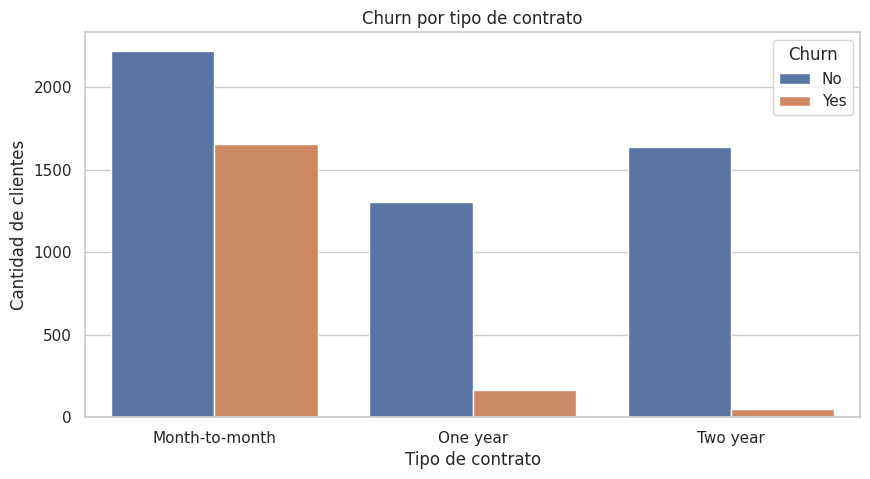

In [29]:
# Gráfico 1 - Churn por tipo de contrato
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.show()

**Gráfico 1 - Churn por tipo de contrato**

El gráfico confirma que el contrato mensual concentra la mayor
cantidad de clientes que abandonan el servicio. Los contratos
anuales y de dos años muestran una tasa de churn casi nula en
comparación, lo que refuerza la hipótesis principal del proyecto.

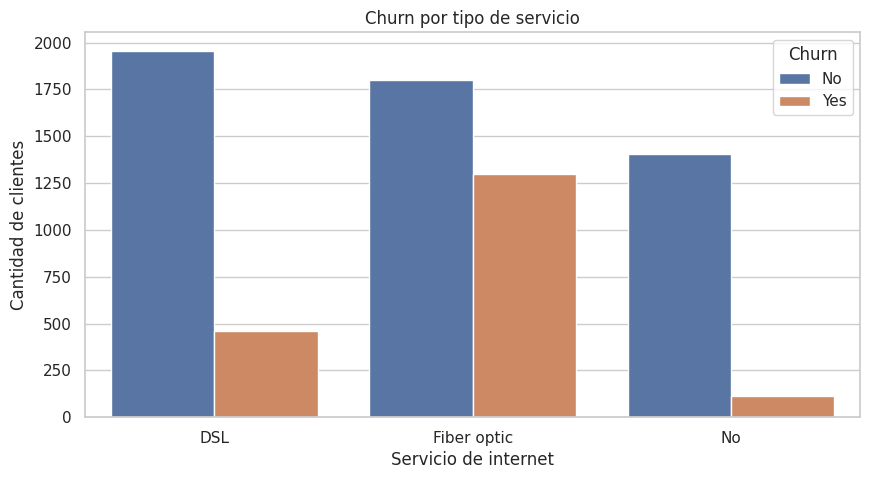

In [30]:
#Grafico 2 - Churn por tipo de servicio de internet
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn por tipo de servicio')
plt.xlabel('Servicio de internet')
plt.ylabel('Cantidad de clientes')
plt.show()

**Gráfico 2 - Churn por tipo de servicio de internet**

La fibra óptica concentra la mayor tasa de abandono, con una
proporción casi igual entre clientes que se quedan y que se van.
DSL muestra un churn moderado y los clientes sin servicio de
internet tienen una tasa de abandono casi nula.
Esto refuerza la hipótesis de que la fibra óptica combinada con
otros factores es el perfil de mayor riesgo.

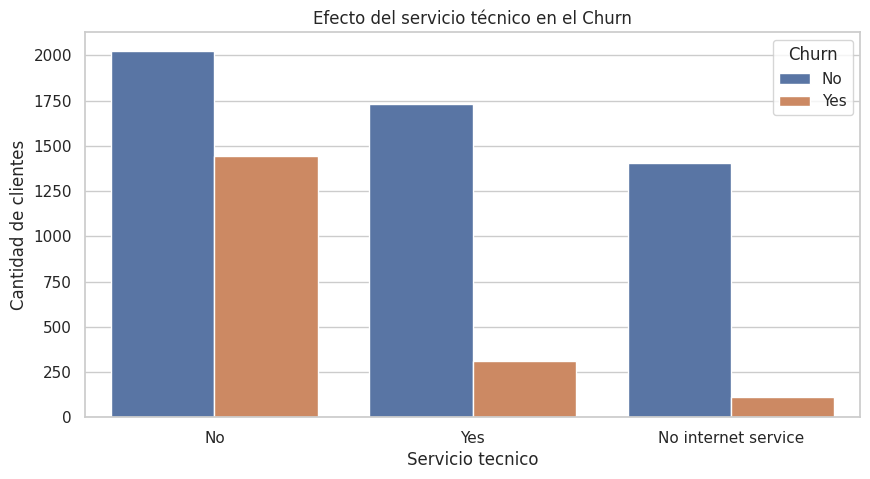

In [31]:
#Grafico 3 - Churn x servicio tecnico
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Efecto del servicio técnico en el Churn')
plt.xlabel('Servicio tecnico')
plt.ylabel('Cantidad de clientes')
plt.show()

**Gráfico 3 - Efecto del soporte técnico en el Churn**

El gráfico muestra que los clientes sin soporte técnico representan
la mayor concentración de churn del dataset. Esto sugiere que más
allá del precio o el tipo de contrato, los clientes valoran sentirse
acompañados y respaldados por la empresa.

Los clientes con soporte técnico muestran una tasa de abandono
significativamente menor, lo que refuerza la recomendación de
negocio: incentivar la contratación del soporte técnico como
estrategia de retención, especialmente en clientes de fibra óptica
con contrato mensual y poca antigüedad.

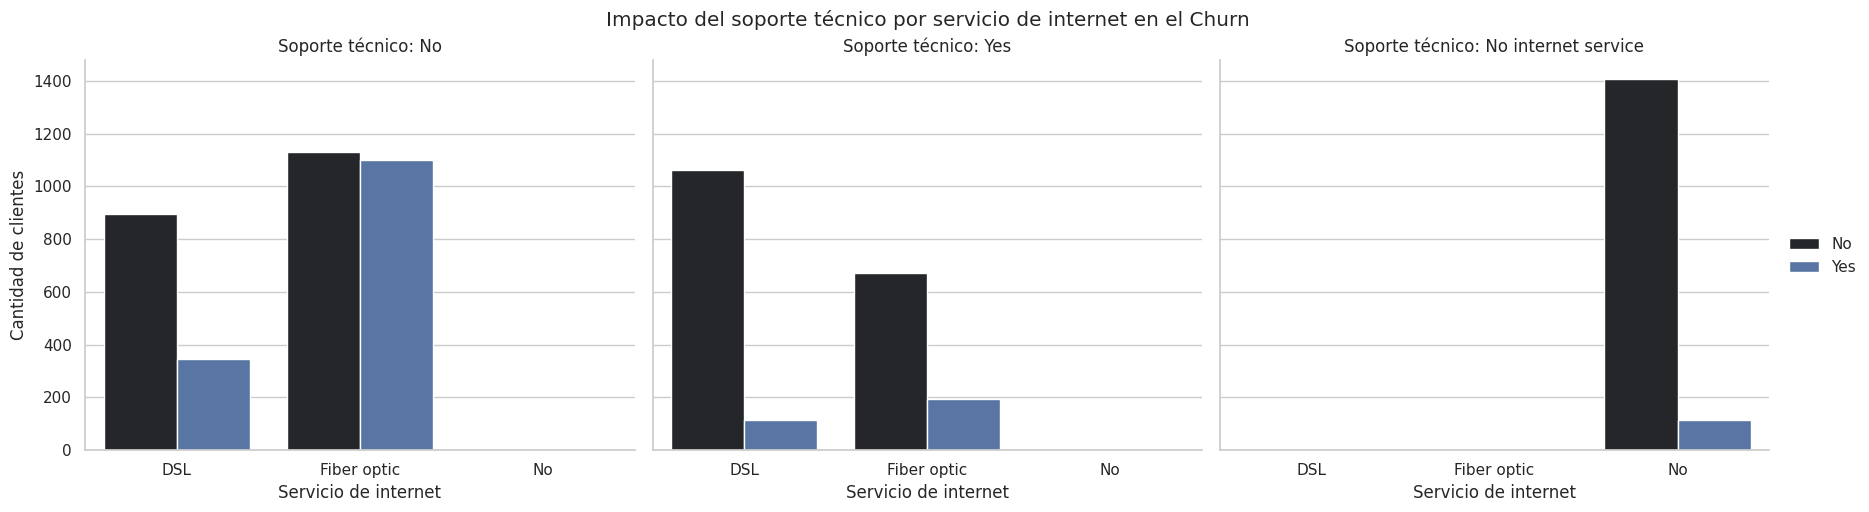

In [32]:
g = sns.FacetGrid(df, col='TechSupport', height=5, aspect=1.2)
g.map_dataframe(sns.countplot, x='InternetService', hue='Churn')
g.add_legend()
g.set_axis_labels('Servicio de internet', 'Cantidad de clientes')
g.set_titles('Soporte técnico: {col_name}')
plt.suptitle('Impacto del soporte técnico por servicio de internet en el Churn',
             y=1.02)
plt.show()

**Gráfico 4 - Impacto del soporte técnico por servicio de internet**

El panel izquierdo muestra que los clientes de fibra óptica SIN
soporte técnico tienen una tasa de churn cercana al 50%, con barras
casi iguales entre los que se van y los que se quedan.

El panel central confirma que tener soporte técnico reduce
drásticamente el churn en fibra óptica, bajando a aproximadamente
23%.

Conclusión: la combinación fibra óptica sin soporte técnico es
el segmento de mayor riesgo y el de mayor potencial de retención
con una inversión relativamente baja.

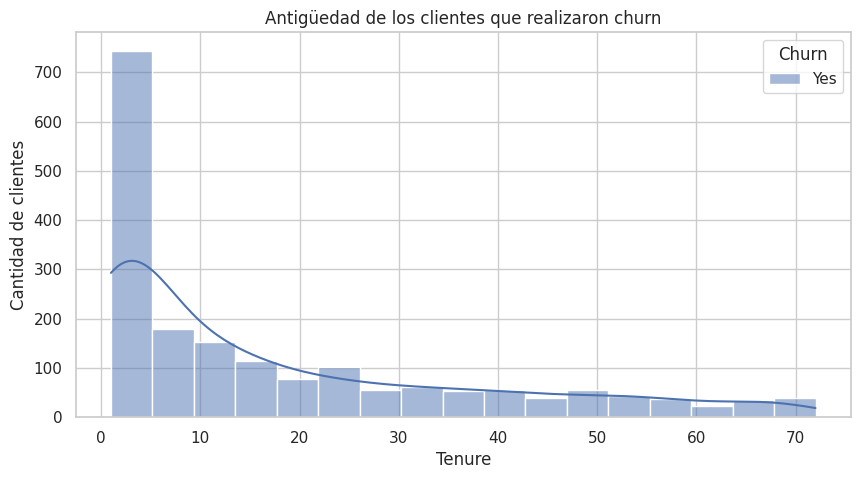

In [33]:
#Grafico 4 - Antigüedad de los clientes que realizaron churn
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_churn,
    x='tenure',
    hue='Churn',
    kde=True
)
plt.title('Antigüedad de los clientes que realizaron churn')
plt.xlabel('Tenure')
plt.ylabel('Cantidad de clientes')
plt.show()

**Gráfico 5 - Antigüedad de los clientes que realizaron churn**

El histograma confirma que el churn se concentra fuertemente en
los primeros meses de vida del cliente. La curva KDE muestra una
caída constante y pronunciada desde el mes 1 hasta aplanarse
cerca de cero a partir del mes 40 aproximadamente.

Esto valida directamente la hipótesis principal del proyecto:
los clientes nuevos (tenure menor a 12 meses) representan el
mayor riesgo de abandono, mientras que los clientes con más
de 3 años de antigüedad tienen una probabilidad de churn
casi nula.

Recomendación: concentrar los esfuerzos de retención en los
primeros 12 meses de vida del cliente es la estrategia con
mayor impacto potencial.

In [34]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


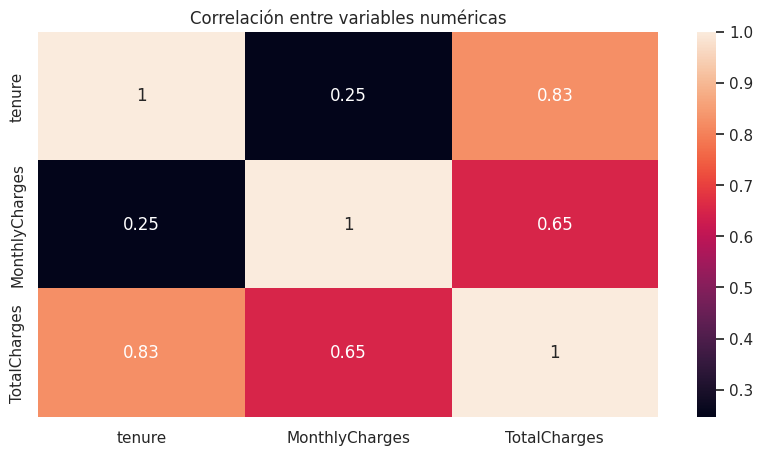

In [35]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True)
plt.title('Correlación entre variables numéricas')
plt.show()


**Gráfico 5 - Correlación entre variables numéricas**

- tenure y TotalCharges (0.83): correlación muy alta.
  A mayor antigüedad, mayor ingreso total generado por el cliente.
- MonthlyCharges y TotalCharges (0.65): correlación moderada.
- tenure y MonthlyCharges (0.24): correlación baja, el precio
  mensual no depende de la antigüedad del cliente.

Conclusión: la antigüedad es la variable numérica más importante
del dataset, tanto por su relación con el churn como por su
impacto en el ingreso total generado por cada cliente.

## 8. Conclusiones del análisis exploratorio

A partir de la limpieza, el EDA y las visualizaciones se identificaron
los siguientes patrones clave:

**Sobre el tipo de contrato:**
- El 43% de los clientes con contrato mensual hizo churn.
- Los contratos anuales y de dos años tienen tasas de abandono
  casi nulas (11% y 3% respectivamente).

**Sobre el servicio de internet:**
- La fibra óptica concentra el 42% de churn, muy por encima
  del DSL (19%) y de los clientes sin internet (7%).

**Sobre el soporte técnico:**
- El 77% de los clientes que hicieron churn no tenía soporte técnico.
- Tener soporte técnico reduce el churn de 42% a 15%.
- La combinación fibra óptica sin soporte técnico alcanza
  un 50% de churn.

**Sobre la antigüedad:**
- Los clientes que se fueron tenían en promedio 18 meses de antigüedad.
- Los que se quedaron tenían en promedio 38 meses.
- A mayor antigüedad, mayor ingreso total generado (correlación 0.83).

## 9. Validación de hipótesis y recomendación de negocio

**Hipótesis confirmada:**
Los datos confirman que los clientes con contrato mensual, menos de
12 meses de antigüedad y sin soporte técnico representan el perfil
de mayor riesgo de churn. La antigüedad alta demostró ser el factor
de retención más fuerte, independientemente del precio y el contrato.

**Recomendación de negocio:**
Implementar una estrategia de retención focalizada en el segmento
de mayor riesgo: clientes de fibra óptica con contrato mensual
y menos de 12 meses de antigüedad que no tienen soporte técnico.

Acciones sugeridas:
- Ofrecer soporte técnico gratuito o con descuento durante
  los primeros 12 meses.
- Incentivar el cambio de contrato mensual a anual con beneficios.
- Focalizar la atención al cliente en el segmento de fibra óptica
  sin soporte técnico.

**Impacto económico estimado:**
- Clientes recuperables: 296
- Ingreso mensual recuperable: USD 25,971
- Ingreso anual recuperable: USD 311,652